## Bibliotecas

In [1]:
import os
import re
import json
import time
import shutil
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import torch
from torch.utils.data import Dataset

from google.colab import files

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    ParameterGrid,
    RepeatedStratifiedKFold
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from sklearn.inspection import permutation_importance

from sklearn.ensemble import RandomForestClassifier

from sklearn.svm import (
    LinearSVC,
    SVC
)

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.utils.class_weight import compute_class_weight

from xgboost import XGBClassifier

In [ ]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Input,
    Embedding,
    LSTM,
    GRU,
    Bidirectional,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModel,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [ ]:
os.makedirs("modelos_tradicionais", exist_ok=True)

## Ajuste dos Dados

In [2]:
df_metrics = pd.read_csv('Corpus_Metrics.csv')

C:\Users\Thiago Lobo\AppData\Local\Temp\ipykernel_14732\808922502.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_metrics = pd.read_csv('Corpus_Metrics.csv')


In [3]:
df_metrics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6618 entries, 0 to 6617
Columns: 201 entries, id_texto to ratio_function_to_content_words
dtypes: float64(199), int64(1), object(1)
memory usage: 10.1+ MB


In [4]:
df = pd.read_csv('Corpus_Final_Resumos_Científicos.csv')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6618 entries, 0 to 6617
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Index     6618 non-null   int64 
 1   Class     6618 non-null   object
 2   Abstract  6618 non-null   object
dtypes: int64(1), object(2)
memory usage: 155.2+ KB


In [6]:
df_main = pd.merge(df, df_metrics,  left_on='Index', right_on='id_texto', how='inner')

In [7]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6618 entries, 0 to 6617
Columns: 204 entries, Index to ratio_function_to_content_words
dtypes: float64(199), int64(2), object(3)
memory usage: 10.3+ MB


In [8]:
# Ajuste na Métrica _Adjetive_ratio

df_main[' adjective_ratio'] = pd.to_numeric(
    df_main[' adjective_ratio'],
    errors='coerce'
)

In [9]:
map_classes = {
    "Humana" : 0,
    "Gerada" : 1,
    "Polida_IA" : 2
}

df_main["label"] = df_main["Class"].map(map_classes)

In [10]:
df_main = df_main.dropna()

In [11]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6582 entries, 0 to 6617
Columns: 205 entries, Index to label
dtypes: float64(200), int64(3), object(2)
memory usage: 10.3+ MB


In [ ]:
df_main.to_csv('df_main.csv', index=False)

## Análise Estatísticas do Corpus

## Análise Discriminante Linear (LDA)

In [ ]:
x = df_main.drop(columns=['Class', 'Index', 'Abstract', 'id_texto'])
y = df_main['Class']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(x)

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)

X_lda = lda.fit_transform(X_scaled, y)

In [ ]:
import pandas as pd

df_lda = pd.DataFrame(X_lda, columns=["LD1", "LD2"])

df_lda["Classe"] = y.values

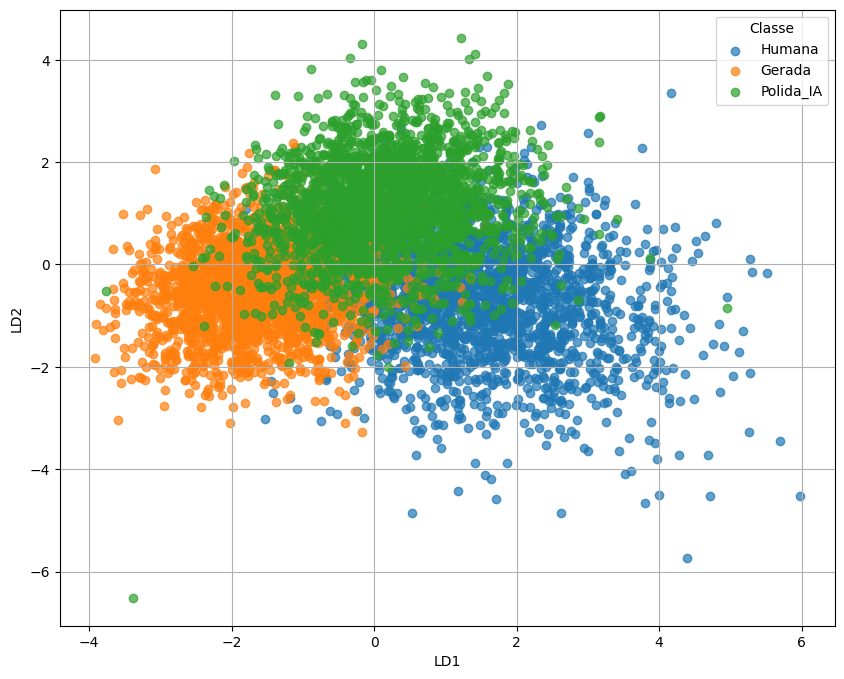

In [ ]:
plt.figure(figsize=(10,8))

for classe in ["Humana", "Gerada", "Polida_IA"]:

    dados = df_lda[df_lda["Classe"] == classe]

    plt.scatter(
        dados["LD1"],
        dados["LD2"],
        label=classe,
        alpha=0.7
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend(title="Classe")
plt.grid(True)

plt.show()

## Segmentação Inicial do Conjunto de Dados

In [ ]:
df_treino, df_teste = train_test_split(
    df_main,
    test_size=0.20,
    random_state=42,
    stratify=df_main["label"]
)

In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

### Análise da Feature Importance na RF

In [ ]:
x_treino = df_treino.drop(
    columns=[
        "Index",
        "Class",
        "Abstract",
        "id_texto"
    ]
)

y_treino = df_treino["Class"]


cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

feature_names = x_treino.columns

importancias = []

top20_frequencia = {
    feature: 0
    for feature in feature_names
}

ranking_soma = {
    feature: 0
    for feature in feature_names
}


for fold, (train_idx, val_idx) in enumerate(
    cv.split(x_treino, y_treino),
    start=1
):

    print(f"Fold {fold}")

    X_train = x_treino.iloc[train_idx]
    X_val = x_treino.iloc[val_idx]

    y_train = y_treino.iloc[train_idx]
    y_val = y_treino.iloc[val_idx]

    rf = RandomForestClassifier(

        n_estimators=300,

        max_depth=None,

        min_samples_split=5,

        min_samples_leaf=2,

        random_state=42,

        n_jobs=-1

    )

    rf.fit(X_train, y_train)

    importance = rf.feature_importances_

    importancias.append(importance)

    ranking = (
        pd.Series(
            importance,
            index=feature_names
        )
        .sort_values(
            ascending=False
        )
    )

    top20 = ranking.head(20).index

    for feature in top20:

        top20_frequencia[feature] += 1

    for posicao, feature in enumerate(
        ranking.index,
        start=1
    ):

        ranking_soma[feature] += posicao

importancias = np.array(importancias)

resultado = pd.DataFrame({

    "Metrica": feature_names,

    "Importancia_Media":
        importancias.mean(axis=0),

    "Importancia_DP":
        importancias.std(axis=0),

    "Frequencia_Top20": [
        top20_frequencia[f]
        for f in feature_names
    ],

    "Ranking_Medio": [
        ranking_soma[f] / len(importancias)
        for f in feature_names
    ]

})

resultado = resultado.sort_values(
    by="Importancia_Media",
    ascending=False
).reset_index(drop=True)

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10
Fold 11
Fold 12
Fold 13
Fold 14
Fold 15
Fold 16
Fold 17
Fold 18
Fold 19
Fold 20
Fold 21
Fold 22
Fold 23
Fold 24
Fold 25
Fold 26
Fold 27
Fold 28
Fold 29
Fold 30
Fold 31
Fold 32
Fold 33
Fold 34
Fold 35
Fold 36
Fold 37
Fold 38
Fold 39
Fold 40
Fold 41
Fold 42
Fold 43
Fold 44
Fold 45
Fold 46
Fold 47
Fold 48
Fold 49
Fold 50


In [ ]:
resultado.head(20)

,Metrica,Importancia_Media,Importancia_DP,Frequencia_Top20,Ranking_Medio
0,words,0.076418,0.002579,50,1.00
1,pronoun_ratio,0.038620,0.001946,50,2.06
2,punctuation_diversity,0.033851,0.001944,50,3.20
3,demonstrative_pronoun_ratio,0.031549,0.002195,50,3.74
4,brunet,0.024034,0.001356,50,5.06
5,idade_aquisicao_mean,0.021171,0.001488,50,5.98
6,pronouns_max,0.017901,0.001340,50,7.46
7,and_ratio,0.016516,0.001375,50,8.20
8,logic_operators,0.015523,0.001370,50,9.32
9,idade_aquisicao_25_4_ratio,0.014613,0.001381,50,10.08


### Método SHAP para determinar a relevância por Classe

In [ ]:
top20_features = resultado.head(20)["Metrica"].tolist()

X_shap = x_treino[top20_features]
y_shap = y_treino

In [ ]:
rf_shap = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_shap.fit(X_shap, y_shap)

RandomForestClassifier(min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
import shap

explainer = shap.TreeExplainer(rf_shap)

shap_values = explainer.shap_values(X_shap)

In [ ]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Número de classes:", len(shap_values))
    for i, values in enumerate(shap_values):
        print(f"Classe {i}: {values.shape}")
else:
    print("Shape:", shap_values.shape)

<class 'numpy.ndarray'>
Shape: (2728, 20, 3)


In [ ]:
classes = rf_shap.classes_

shap_importance = {}

for i, classe in enumerate(classes):

    if isinstance(shap_values, list):
        values = shap_values[i]

    else:
        values = shap_values[:, :, i]

    shap_importance[classe] = np.abs(values).mean(axis=0)


resultado_shap = pd.DataFrame(
    shap_importance,
    index=top20_features
)

resultado_shap.index.name = "Metrica"

resultado_shap = resultado_shap.sort_values(
    by=classes.tolist()[0],
    ascending=False
)

resultado_shap

,Gerada,Humana,Polida_IA
Metrica,,,
words,0.130350,0.108187,0.081218
pronoun_ratio,0.068626,0.026174,0.045241
demonstrative_pronoun_ratio,0.066054,0.015747,0.059659
punctuation_diversity,0.041077,0.049324,0.023089
logic_operators,0.025391,0.009106,0.017956
idade_aquisicao_mean,0.024250,0.047102,0.026516
pronouns_max,0.024141,0.009034,0.016831
and_ratio,0.022725,0.009177,0.016269
flesch,0.017024,0.008489,0.014053


<Axes: title={'center': 'Importância SHAP das métricas — Classe Humana'}, ylabel='Metrica'>

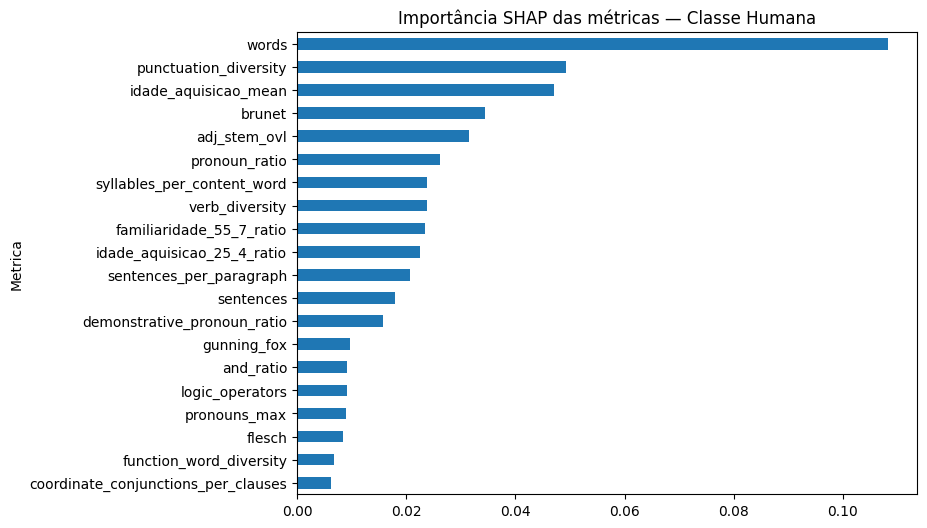

In [ ]:
shap_humana = resultado_shap.sort_values(
    by="Humana",
    ascending=True
)

shap_humana["Humana"].plot.barh(
    figsize=(8, 6),
    title="Importância SHAP das métricas — Classe Humana"
)

<Axes: title={'center': 'Importância SHAP das métricas — Classe Gerada'}, ylabel='Metrica'>

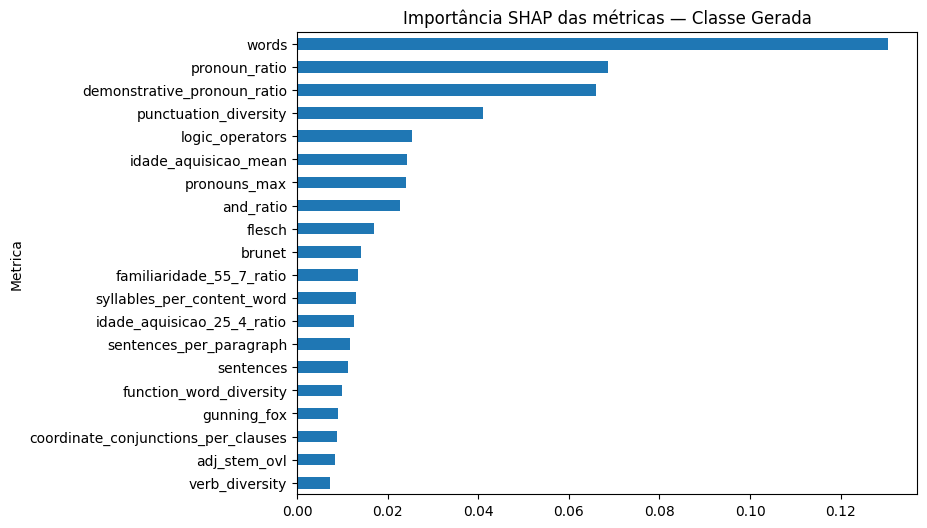

In [ ]:
shap_gerada = resultado_shap.sort_values(
    by="Gerada",
    ascending=True
)

shap_gerada["Gerada"].plot.barh(
    figsize=(8, 6),
    title="Importância SHAP das métricas — Classe Gerada"
)

<Axes: title={'center': 'Importância SHAP das métricas — Classe Polida IA'}, ylabel='Metrica'>

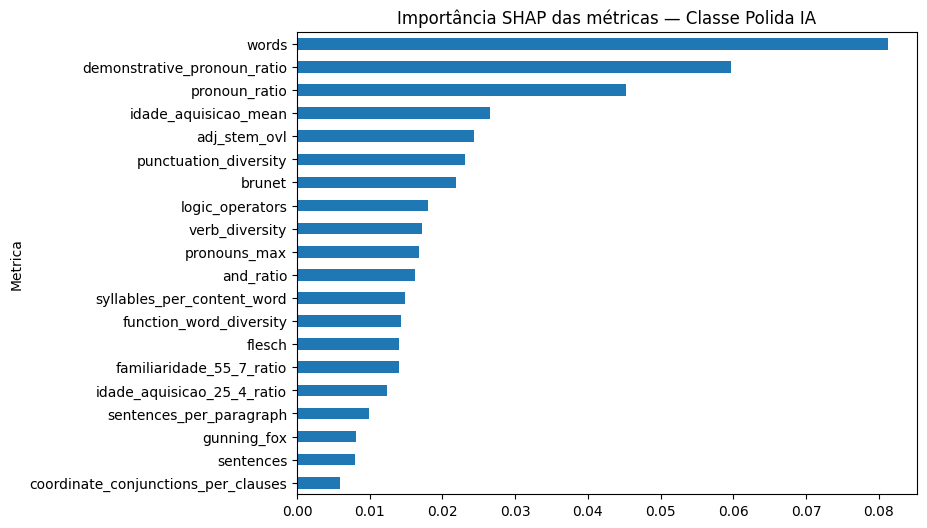

In [ ]:
shap_polida = resultado_shap.sort_values(
    by="Polida_IA",
    ascending=True
)

shap_polida["Polida_IA"].plot.barh(
    figsize=(8, 6),
    title="Importância SHAP das métricas — Classe Polida IA"
)

In [ ]:
classes = rf_shap.classes_

shap_direction = {}

for i, classe in enumerate(classes):

    if isinstance(shap_values, list):
        values = shap_values[i]

    else:
        values = shap_values[:, :, i]

    # Média dos valores SHAP COM sinal
    shap_direction[classe] = values.mean(axis=0)


resultado_shap_direcao = pd.DataFrame(
    shap_direction,
    index=top20_features
)

resultado_shap_direcao.index.name = "Metrica"

# Ordenar pela maior contribuição positiva para a primeira classe
resultado_shap_direcao = resultado_shap_direcao.sort_values(
    by=classes[0],
    ascending=False
)

resultado_shap_direcao

,Gerada,Humana,Polida_IA
Metrica,,,
sentences_per_paragraph,0.001517,-0.002383,0.000867
sentences,0.001360,-0.002326,0.000966
idade_aquisicao_mean,0.000995,-0.000490,-0.000505
brunet,0.000747,-0.003170,0.002423
verb_diversity,0.000481,-0.001491,0.001010
punctuation_diversity,0.000352,-0.000511,0.000159
adj_stem_ovl,0.000340,-0.001158,0.000817
familiaridade_55_7_ratio,0.000251,-0.001028,0.000777
pronoun_ratio,0.000144,0.001080,-0.001224


### Abordagens tradicionais de Aprendizado de Máquina

In [ ]:
modelos = {
    "RF": {
        "modelo": RandomForestClassifier(random_state=42, n_jobs=-1),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "max_depth": [None, 20, 40],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2]
        }
    },

    "SVC_Linear": {
        "modelo": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LinearSVC(random_state=42, max_iter=10000))
        ]),
        "param_grid": {
            "clf__C": [0.01, 0.1, 1, 10, 100]
        }
    },

    "SVC_RBF": {
        "modelo": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", random_state=42))
        ]),
        "param_grid": {
            "clf__C": [0.1, 1, 10, 100],
            "clf__gamma": ["scale", 0.01, 0.1, 1]
        }
    },

    "XGBoost": {
        "modelo": XGBClassifier(
            random_state=42,
            eval_metric="mlogloss",
            n_jobs=-1
        ),
        "param_grid": {
            "n_estimators": [100, 200, 300],
            "max_depth": [4, 6, 8],
            "learning_rate": [0.01, 0.05, 0.1]
        }
    }
}

In [ ]:
def treinar_modelos_tradicionais_com_cv(modelos, X_train, y_train, X_test, y_test, k=10, caminho_json="resultados_modelos_tradicionais.json"):

    resultados = {}

    for nome_modelo, config in modelos.items():

        print(f"\nTestando modelo: {nome_modelo}")

        modelo_base = config["modelo"]
        param_grid = config["param_grid"]

        melhor_f1 = -1
        melhores_hiperparametros = None
        f1_scores_por_combinacao = {}

        inicio_grid = time.time()

        for params in ParameterGrid(param_grid):

            chave_params = "_".join([f"{k}_{v}" for k, v in params.items()])
            print(f"Testando: {params}")

            f1_scores = []

            for train_idx, val_idx in skf.split(X_train, y_train):

                X_train_fold = X_train.iloc[train_idx]
                X_val_fold = X_train.iloc[val_idx]

                y_train_fold = y_train.iloc[train_idx]
                y_val_fold = y_train.iloc[val_idx]

                modelo = modelo_base.set_params(**params)

                modelo.fit(X_train_fold, y_train_fold)

                y_pred_val = modelo.predict(X_val_fold)

                f1 = f1_score(y_val_fold, y_pred_val,average="macro")

                f1_scores.append(f1)

            f1_scores_por_combinacao[chave_params] = f1_scores

            media_f1 = np.mean(f1_scores)

            print(f"F1 Macro médio: {media_f1:.4f}")

            if media_f1 > melhor_f1:
                melhor_f1 = media_f1
                melhores_hiperparametros = params

        tempo_total_grid = time.time() - inicio_grid

        print(f"\nMelhores hiperparâmetros para {nome_modelo}:")
        print(melhores_hiperparametros)

        # Treinamento final com todos os dados de treino
        modelo_final = modelo_base.set_params(**melhores_hiperparametros)

        inicio_final = time.time()
        modelo_final.fit(X_train, y_train)
        tempo_treinamento_final = time.time() - inicio_final

        y_pred_test = modelo_final.predict(X_test)

        acc_final = accuracy_score(y_test, y_pred_test)
        f1_macro_final = f1_score(y_test, y_pred_test, average="macro")

        report = classification_report(
            y_test,
            y_pred_test,
            output_dict=True
        )

        matriz = confusion_matrix(y_test, y_pred_test)

        resultados[nome_modelo] = {
            "melhores_hiperparametros": melhores_hiperparametros,
            "tempo_total_combinacoes_e_cv": tempo_total_grid,
            "tempo_treinamento_final": tempo_treinamento_final,
            "acc_final": acc_final,
            "f1_score_macro_final": f1_macro_final,
            "classification_report": report,
            "matriz_confusao": matriz.tolist(),
            "f1_scores_por_combinacao": f1_scores_por_combinacao
        }

        # Salva o Modelo
        joblib.dump(modelo_final, f"modelos_tradicionais/{nome_modelo}.pkl")

        # Salva um JSON por modelo
        with open(f"resultados_modelos_{nome_modelo}.json", "w", encoding="utf-8") as f:
            json.dump({nome_modelo: resultados[nome_modelo]}, f, indent=4, ensure_ascii=False)

        print(f"\nResultado final - {nome_modelo}")
        print(f"Accuracy: {acc_final:.4f}")
        print(f"F1 Macro: {f1_macro_final:.4f}")

    return resultados

In [ ]:
X_train, y_train = df_treino.drop(columns=["Index",	"Class",	"Abstract",	"id_texto", "label"]), df_treino["label"]
X_test, y_test = df_teste.drop(columns=["Index",	"Class",	"Abstract",	"id_texto", "label"]), df_teste["label"]

resultados_tradicionais = treinar_modelos_tradicionais_com_cv(
    modelos=modelos,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    k=10,
    caminho_json="resultados_modelos_tradicionais.json"
)

In [ ]:
top20_features = [
    "words",
    "pronoun_ratio",
    "demonstrative_pronoun_ratio",
    "punctuation_diversity",
    "brunet",
    "pronouns_max",
    "idade_aquisicao_mean",
    "idade_aquisicao_25_4_ratio",
    "and_ratio",
    "sentences_per_paragraph",
    "sentences",
    "logic_operators",
    "familiaridade_55_7_ratio",
    "verb_diversity",
    "adj_stem_ovl",
    "function_word_diversity",
    "verbs_min",
    "syllables_per_content_word",
    "pronouns_standard_deviation",
    "gunning_fox"
]

X_train, y_train = df_treino[top20_features], df_treino["label"]
X_test, y_test = df_teste[top20_features], df_teste["label"]

resultados_tradicionais = treinar_modelos_tradicionais_com_cv(
    modelos=modelos,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    k=10,
    caminho_json="resultados_modelos_tradicionais_top_20_metricas.json"
)


Testando modelo: RF
Testando: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
F1 Macro médio: 0.7981
Testando: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
F1 Macro médio: 0.7972
Testando: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
F1 Macro médio: 0.7978
Testando: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
F1 Macro médio: 0.7966
Testando: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
F1 Macro médio: 0.7966
Testando: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
F1 Macro médio: 0.7961
Testando: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
F1 Macro médio: 0.7958
Testando: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
F1 Macro médio: 0.7968
Testando: {

### Abordagens de Redes Neurais Recorrentes e Transformers

#### Arquiteturas Recorrentes

In [ ]:
MODEL_NAME = "neuralmind/bert-base-portuguese-cased"
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 768

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

model.eval()

def bert_embed_abstracts(texts):
    embeddings = []

    for i, text in enumerate(texts):
        tokens = tokenizer(text, padding='max_length', truncation=True, max_length=MAX_SEQUENCE_LENGTH, return_tensors='pt')

        with torch.no_grad():
            outputs = model(**tokens)
            print(f"Sentença {i+1}/{len(texts)} processada")

            token_embeddings = outputs.last_hidden_state.squeeze(0).numpy()

        if token_embeddings.shape[0] < MAX_SEQUENCE_LENGTH:
            padding = np.zeros((MAX_SEQUENCE_LENGTH - token_embeddings.shape[0], EMBEDDING_DIM))
            token_embeddings = np.vstack([token_embeddings, padding])
        else:
            token_embeddings = token_embeddings[:MAX_SEQUENCE_LENGTH]

        embeddings.append(token_embeddings)

    return np.array(embeddings)

In [ ]:
X_train = bert_embed_abstracts(df_treino["Abstract"])
y_train = df_treino["label"]
X_test = bert_embed_abstracts(df_teste["Abstract"])
y_test = df_teste["label"]

In [ ]:
# Funções para construir modelos

def build_lstm(input_shape, num_class, units1, dropout, learning_rate):
    model = Sequential([
        Input(shape=(input_shape)),
        LSTM(units1, return_sequences=True),
        LSTM(64),
        Dropout(dropout),
        Dense(num_class, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_gru(input_shape, num_class, units1, dropout, learning_rate):
    model = Sequential([
        Input(shape=(input_shape)),
        GRU(units1, return_sequences=True),
        GRU(64),
        Dropout(dropout),
        Dense(num_class, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_bilstm(input_shape, num_class, units1, dropout, learning_rate):
    model = Sequential([
        Input(shape=(input_shape)),
        Bidirectional(LSTM(units1, return_sequences=True)),
        Bidirectional(LSTM(64)),
        Dropout(dropout),
        Dense(num_class, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_bigru(input_shape, num_class, units1, dropout, learning_rate):
    model = Sequential([
        Input(shape=(input_shape)),
        Bidirectional(GRU(units1, return_sequences=True)),
        Bidirectional(GRU(64)),
        Dropout(dropout),
        Dense(num_class, activation='softmax')
    ])
    model.compile(optimizer=Adam(learning_rate), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# Dicionário de modelos
modelos = {
    'LSTM': build_lstm,
    'GRU': build_gru,
    'BiLSTM': build_bilstm,
    'BiGRU': build_bigru
}

#hiperparâmetros
param_grid = {
    'units_layer_one': [64, 128],
    'dropout': [0.1, 0.3, 0.5],
    'learning_rate': [0.001, 0.003, 0.005]
}

# Função principal
def treinar_modelos_com_cv(modelos, param_grid, X_train, y_train, X_test, y_test, k, epochs, batch_size):
    resultados = {}

    for nome_modelo, construtor in modelos.items():
        print(f'\n Testando modelo: {nome_modelo}')
        melhor_score = 0
        melhor_comb = None
        f1_scores_por_combinacao = {}
        inicio_total_modelo = time.time()

        for u1 in param_grid['units_layer_one']:
            for dropout in param_grid['dropout']:
                for lr in param_grid['learning_rate']:
                    print(f'Testando: u1={u1}, dropout={dropout}, lr={lr}')
                    scores = []
                    f1_scores = []

                    for train_idx, val_idx in skf.split(X_train, y_train):
                        X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
                        y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

                        num_class = len(np.unique(y_train))
                        model = construtor(X_train.shape[1:], num_class, u1, dropout, lr)
                        model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold), epochs=epochs, batch_size=batch_size, verbose=0, callbacks=[early_stopping])

                        preds = np.argmax(model.predict(X_val_fold, verbose=0), axis=1)

                        acc = np.mean(preds == y_val_fold)
                        f1 = f1_score(y_val_fold, preds, average='macro')
                        scores.append(acc)
                        f1_scores.append(f1)

                    media_f1 = np.mean(f1_scores)
                    chave = f'u{u1}_d{dropout}_lr{lr}'
                    f1_scores_por_combinacao[chave] = f1_scores  # <-- Armazenando os F1-scores por fold

                    print(f'→ F1-Score médio (macro): {media_f1:.4f}')

                    if media_f1 > melhor_score:
                        melhor_score = media_f1
                        melhor_comb = (u1, dropout, lr)

        tempo_total_modelo = time.time() - inicio_total_modelo

        print(f'\n Melhor combinação para {nome_modelo}: {melhor_comb} com F1-score médio: {melhor_score:.4f}')

        # Treinamento final
        print(f' Treinando modelo final {nome_modelo}...')
        u1, dropout, lr = melhor_comb

        model_final = construtor(X_train.shape[1:], num_class, u1, dropout, lr)
        inicio_treinamento_final = time.time()
        history = model_final.fit(X_train, y_train, validation_split=0.10, epochs=epochs, batch_size=batch_size, verbose=1, callbacks=[early_stopping])

        # Salvar modelo final
        model_final.save(f"modelos_treinados/modelo_{nome_modelo}.keras")

        # Tempo de Treinamento
        tempo_treinamento_final = time.time() - inicio_treinamento_final

        preds_test = np.argmax(model_final.predict(X_test, verbose=1), axis=1)

        report = classification_report(y_test, preds_test, output_dict=True)
        cm = confusion_matrix(y_true_test, preds_test).tolist()

        # Acc & F1 macro final do modelo
        acc_final = np.mean(preds_test == y_test)
        f1_macro_final = report['macro avg']['f1-score']
        print(f' F1-score (macro) final do modelo {nome_modelo}: {f1_macro_final:.4f}')
        print(f' Acurácia final do modelo {nome_modelo}: {acc_final:.4f}')

        print(f' Resultados do modelo final ({nome_modelo}):\n{classification_report(y_true_test, preds_test)}')

        # Salvar modelo final
        model.save(f"modelos_treinados/modelo_{nome_modelo}.keras")

        resultados[nome_modelo] = {
            'melhores_hiperparametros': {'units': u1, 'dropout': dropout, 'lr': lr},
            'tempo_total_combinacoes_e_cv': tempo_total_modelo,
            'tempo_treinamento_final': tempo_treinamento_final,
            'acc_final': acc_final,
            'f1_score_macro_final': f1_macro_final,
            'classification_report': report,
            'matriz_confusao': cm,
            'acc_por_epoca': [float(v) for v in history.history['accuracy']],
            'loss_por_epoca': [float(v) for v in history.history['loss']],
            'f1_scores_por_combinacao': f1_scores_por_combinacao
        }


        caminho = f"resultados_modelos_{nome_modelo}.json"  # salvar no diretório atual
        with open(caminho, "w") as f:
            json.dump(resultados, f, indent=4)


        try:
            from google.colab import files
            files.download(caminho)
        except:
            print("Download automático não disponível fora do Google Colab.")

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

# Executar
treinar_modelos_com_cv(modelos=modelos, param_grid=param_grid, X_train, y_train, X_test, y_test, k=10, epochs=30, batch_size=32)

#### Abordagens baseadas em Transformers

In [ ]:
X_train = df_treino["Abstract"].values
y_train = df_treino["Class"].values

X_test = df_teste["Abstract"].values
y_test = df_teste["Class"].values

In [ ]:
MAX_LEN = 200
EPOCHS = 4
BATCH = 32
NUM_LABELS = 3
k = 10

In [ ]:
# Desativa W&B
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
modelos_bert = {
    "BERTimbau_Large": "neuralmind/bert-large-portuguese-cased",
    "DistilBERT": "distilbert-base-multilingual-cased",
    "XLM-RoBERTa": "xlm-roberta-base"
}

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            key: tensor[idx]
            for key, tensor in self.encodings.items()
        }

        item["labels"] = self.labels[idx]

        return item

In [ ]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="macro",
        zero_division=0
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall
    }

In [ ]:
learning_rates = [0.00001, 0.00002, 0.00003, 0.00005]

resultados_cv = []
melhores_lrs = []

for nome_modelo, nome_checkpoint in modelos_bert.items():

    print(f"\nModelo: {nome_modelo}")
    tokenizer = AutoTokenizer.from_pretrained(nome_checkpoint)

    melhor_lr = None
    melhor_f1_medio = 0

    for lr in learning_rates:

        print(f"\nTestando LR: {lr}")

        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):

            print(f"Modelo: {nome_modelo} | LR: {lr} | Fold: {fold}")

            X_train_fold, X_val_fold = X_train[train_idx], X_train[val_idx]
            y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

            train_enc = tokenizer(
                list(X_train_fold),
                truncation=True,
                padding="max_length",
                max_length=MAX_LEN,
                return_tensors="pt"
            )

            val_enc = tokenizer(
                list(X_val_fold),
                truncation=True,
                padding="max_length",
                max_length=MAX_LEN,
                return_tensors="pt"
            )

            train_dataset = CustomDataset(train_enc, torch.tensor(y_train_fold))
            val_dataset = CustomDataset(val_enc, torch.tensor(y_val_fold))

            model = AutoModelForSequenceClassification.from_pretrained(nome_checkpoint, num_labels=NUM_LABELS)

            args = TrainingArguments(
                output_dir=f"./resultados_cv_{nome_modelo}_lr_{lr}_fold_{fold}",
                eval_strategy="epoch",
                save_strategy="epoch",

                save_total_limit=1,
                load_best_model_at_end=True,

                learning_rate=lr,
                per_device_train_batch_size=BATCH,
                per_device_eval_batch_size=BATCH,
                num_train_epochs=EPOCHS,
                weight_decay=0.01,

                metric_for_best_model="f1",
                greater_is_better=True,

                logging_dir=f"./logs_cv_{nome_modelo}_lr_{lr}_fold_{fold}",
                report_to=[],

                fp16=torch.cuda.is_available(),
                eval_accumulation_steps=1
            )

            trainer = Trainer(model=model, args=args,  train_dataset=train_dataset, eval_dataset=val_dataset,compute_metrics=compute_metrics)

            trainer.train()
            metrics = trainer.evaluate()

            f1_fold = metrics["eval_f1"]
            fold_scores.append(f1_fold)

            resultados_cv.append({
                "modelo": nome_modelo,
                "checkpoint": nome_checkpoint,
                "learning_rate": lr,
                "fold": fold,
                "f1_macro": f1_fold,
                "accuracy": metrics["eval_accuracy"],
                "precision_macro": metrics["eval_precision"],
                "recall_macro": metrics["eval_recall"]
            })

            del model
            del trainer
            del train_enc
            del val_enc
            del train_dataset
            del val_dataset
            del X_train_fold
            del X_val_fold
            del y_train_fold
            del y_val_fold

            torch.cuda.empty_cache()
            gc.collect()

            shutil.rmtree(
                f"./resultados_cv_{nome_modelo}_lr_{lr}_fold_{fold}",
                ignore_errors=True
            )

            shutil.rmtree(
                f"./logs_cv_{nome_modelo}_lr_{lr}_fold_{fold}",
                ignore_errors=True
            )

        f1_medio = np.mean(fold_scores)
        f1_desvio = np.std(fold_scores)

        print(f"\nLR: {lr}")
        print(f"F1 médio: {f1_medio:.4f}")
        print(f"Desvio padrão: {f1_desvio:.4f}")

        if f1_medio > melhor_f1_medio:
            melhor_f1_medio = f1_medio
            melhor_lr = lr

    melhores_lrs.append({
        "modelo": nome_modelo,
        "checkpoint": nome_checkpoint,
        "melhor_learning_rate": melhor_lr,
        "melhor_f1_medio_cv": melhor_f1_medio
    })

    print(f"\nMelhor LR para {nome_modelo}: {melhor_lr}")
    print(f"Melhor F1 médio CV: {melhor_f1_medio:.4f}")

    del tokenizer
    gc.collect()


df_resultados_cv = pd.DataFrame(resultados_cv)
df_resultados_cv.to_csv("resultados_validacao_cruzada_lr.csv", index=False)
files.download("resultados_validacao_cruzada_lr.csv")

df_melhores_lrs = pd.DataFrame(melhores_lrs)
df_melhores_lrs.to_csv("melhores_lrs_por_modelo.csv", index=False)
files.download("melhores_lrs_por_modelo.csv")

In [ ]:
df_melhores_lrs = pd.read_csv("melhores_lrs_por_modelo.csv")

resultados_teste = []

for _, row in df_melhores_lrs.iterrows():

    nome_modelo = row["modelo"]
    nome_checkpoint = row["checkpoint"]
    melhor_lr = float(row["melhor_learning_rate"])
    melhor_f1_medio = row["melhor_f1_medio_cv"]

    print(f"\n==============================")
    print(f"Treino final: {nome_modelo}")
    print(f"Checkpoint: {nome_checkpoint}")
    print(f"Melhor LR: {melhor_lr}")
    print(f"F1 médio CV: {melhor_f1_medio:.4f}")
    print(f"==============================")

    tokenizer = AutoTokenizer.from_pretrained(nome_checkpoint)

    start_final = time.time()

    X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
        X_train,
        y_train,
        test_size=0.10,
        stratify=y_train,
        random_state=42
    )

    train_enc_final = tokenizer(
        list(X_train_final),
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    val_enc_final = tokenizer(
        list(X_val_final),
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    test_enc = tokenizer(
        list(X_test),
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN,
        return_tensors="pt"
    )

    train_dataset_final = CustomDataset(
        train_enc_final,
        torch.tensor(y_train_final)
    )

    val_dataset_final = CustomDataset(
        val_enc_final,
        torch.tensor(y_val_final)
    )

    test_dataset = CustomDataset(
        test_enc,
        torch.tensor(y_test)
    )

    model_final = AutoModelForSequenceClassification.from_pretrained(
        nome_checkpoint,
        num_labels=NUM_LABELS
    )

    args_final = TrainingArguments(
        output_dir=f"./modelo_final_{nome_modelo}_lr_{melhor_lr}",
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,

        learning_rate=melhor_lr,

        per_device_train_batch_size=BATCH,
        per_device_eval_batch_size=BATCH,

        num_train_epochs=EPOCHS,
        weight_decay=0.01,

        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,

        logging_dir=f"./logs_final_{nome_modelo}_lr_{melhor_lr}",

        report_to=[],

        fp16=torch.cuda.is_available(),
        eval_accumulation_steps=1
    )

    trainer_final = Trainer(
        model=model_final,
        args=args_final,
        train_dataset=train_dataset_final,
        eval_dataset=val_dataset_final,
        compute_metrics=compute_metrics
    )

    trainer_final.train()

    modelo_final_path = f"./modelo_final_{nome_modelo}_melhor_lr_{melhor_lr}"

    trainer_final.save_model(modelo_final_path)
    tokenizer.save_pretrained(modelo_final_path)

    test_metrics = trainer_final.evaluate(test_dataset)
    predictions = trainer_final.predict(test_dataset)
    preds = predictions.predictions.argmax(-1)

    cm = confusion_matrix(y_test, preds, labels=[0, 1, 2])

    report = classification_report(
        y_test,
        preds,
        labels=[0, 1, 2],
        output_dict=True,
        zero_division=0
    )

    tempo_final = time.time() - start_final

    test_metrics["modelo"] = nome_modelo
    test_metrics["checkpoint"] = nome_checkpoint
    test_metrics["melhor_learning_rate"] = melhor_lr
    test_metrics["melhor_f1_medio_cv"] = melhor_f1_medio
    test_metrics["tempo_treinamento"] = tempo_final

    test_metrics["classification_report"] = report

    test_metrics["confusion_matrix"] = {
        "labels": [0, 1, 2],
        "matrix": cm.tolist()
    }

    resultados_teste.append(test_metrics)

    with open(f"{nome_modelo}_test_metrics_final.json", "w") as f:
        json.dump(test_metrics, f, indent=4)

    history = trainer_final.state.log_history
    df_history = pd.DataFrame([m for m in history if "eval_loss" in m])
    df_history.to_csv(f"{nome_modelo}_final_metrics.csv", index=False)

    shutil.make_archive(modelo_final_path, "zip", modelo_final_path)

    files.download(f"{modelo_final_path}.zip")
    files.download(f"{nome_modelo}_test_metrics_final.json")
    files.download(f"{nome_modelo}_final_metrics.csv")

    tempo_final = time.time() - start_final
    print(f"Tempo do treino final ({nome_modelo}): {tempo_final:.2f} segundos")

    del model_final
    del trainer_final
    torch.cuda.empty_cache()


df_resultados_teste = pd.DataFrame(resultados_teste)
df_resultados_teste.to_csv("resultados_teste_final_modelos.csv", index=False)
files.download("resultados_teste_final_modelos.csv")